# NIVEL MEDIO - Calidad de Datos con Funciones

Este notebook implementa el análisis de calidad de datos usando funciones reutilizables para el dataset SISMEPRE de la capa silver.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## Funciones de Análisis de Calidad

In [2]:
def _normalizar_vacios(df):
    """Convierte campos vacíos o espacios en NaN para mejorar el análisis"""
    return df.replace(r'^\s*$', np.nan, regex=True)

def _fecha_valida(serie, formato=None):
    """Convierte una serie a datetime sin detener el notebook por valores inválidos"""
    return pd.to_datetime(serie, format=formato, errors='coerce')

def analizar_completitud(df):
    """Analiza datos faltantes en el DataFrame"""
    df_limpio = _normalizar_vacios(df)
    missing_data = df_limpio.isnull().sum()
    missing_percent = (missing_data / len(df_limpio)) * 100
    
    completitud = pd.DataFrame({
        'Faltantes': missing_data,
        'Porcentaje': missing_percent
    }).sort_values('Porcentaje', ascending=False)
    
    return completitud[completitud['Faltantes'] > 0]

def analizar_exactitud(df):
    """Detecta valores numéricos incorrectos"""
    resultados = {
        'anos_aplicacion_invalidos': df[df['ANO_APLICACION'] != 2022],
        'meses_estadistica_invalidos': df[~df['MES_ESTADISTICA'].between(1, 12)],
        'respuestas_numericas_negativas': df[(df['RESPUESTA_DECIMAL'] < 0) | (df['RESPUESTA_ENTERO'] < 0)]
    }
    return resultados

def analizar_consistencia(df, reglas_estado):
    """Verifica coherencia entre campos relacionados"""
    df_copy = df.copy()
    df_copy['fecha_resolucion_dt'] = _fecha_valida(df_copy['FECHA_RESOL_ALCAL_ADJUNTO'].replace('0', np.nan), formato='%d/%m/%Y %H:%M:%S')
    df_copy['tiene_fecha_resolucion'] = df_copy['fecha_resolucion_dt'].notna()
    
    resolucion_sin_fecha = df_copy[(df_copy['IND_RESOL_ALCAL_ADJUNTO'] == 'A') & (~df_copy['tiene_fecha_resolucion'])]
    fecha_sin_resolucion = df_copy[(df_copy['IND_RESOL_ALCAL_ADJUNTO'] != 'A') & (df_copy['tiene_fecha_resolucion'])]
    anio_desc_inconsistente = df_copy[df_copy['ANO_ESTADISTICA'] != df_copy['ANO_ESTADISTICA_DESC']]
    estados_no_definidos = df_copy[~df_copy['IND_RESOL_ALCAL_ADJUNTO'].isin(reglas_estado.keys())]
    
    return {
        'resolucion_sin_fecha': resolucion_sin_fecha,
        'fecha_sin_resolucion': fecha_sin_resolucion,
        'anio_desc_inconsistente': anio_desc_inconsistente,
        'estados_no_definidos': estados_no_definidos
    }

def analizar_integridad(df):
    """Valida que los IDs estén en el rango esperado"""
    ids_invalidos = df[
        (df['SEC_EJEC'] <= 0) |
        (df['FORMULARIO_ID'] <= 0) |
        (df['PREGUNTA_ID'] <= 0) |
        (df['RESPUESTA_ID'] <= 0)
    ]
    return ids_invalidos

def analizar_razonabilidad(df, anio_min=2000, anio_max=2030):
    """Detecta valores fuera de rangos razonables"""
    return {
        'anios_estadistica_fuera_rango': df[~df['ANO_ESTADISTICA'].between(anio_min, anio_max)],
        'periodos_invalidos': df[df['PERIODO'] <= 0],
        'respuestas_extremas': df[(df['RESPUESTA_DECIMAL'].abs() > 1_000_000) | (df['RESPUESTA_ENTERO'].abs() > 1_000_000)]
    }

def analizar_oportunidad(df):
    """Valida que las fechas estén en un rango temporal apropiado"""
    df_copy = df.copy()
    df_copy['usuario_creacion_dt'] = _fecha_valida(df_copy['USUARIO_CREACION_FECHA'])
    df_copy['usuario_envio_dt'] = _fecha_valida(_normalizar_vacios(df_copy[['USUARIO_FECHA_ENVIO']])['USUARIO_FECHA_ENVIO'])
    df_copy['fecha_respuesta_dt'] = _fecha_valida(_normalizar_vacios(df_copy[['RESPUESTA_FECHA']])['RESPUESTA_FECHA'], formato='%d/%m/%Y %H:%M:%S')
    df_copy['fecha_resolucion_dt'] = _fecha_valida(df_copy['FECHA_RESOL_ALCAL_ADJUNTO'].replace('0', np.nan), formato='%d/%m/%Y %H:%M:%S')
    
    return {
        'creacion_no_parseable': df_copy[df_copy['usuario_creacion_dt'].isna()],
        'respuesta_anterior_creacion': df_copy[(df_copy['fecha_respuesta_dt'].notna()) & (df_copy['fecha_respuesta_dt'] < df_copy['usuario_creacion_dt'])],
        'resolucion_anterior_creacion': df_copy[(df_copy['fecha_resolucion_dt'].notna()) & (df_copy['fecha_resolucion_dt'] < df_copy['usuario_creacion_dt'])]
    }

def analizar_unicidad(df):
    """Detecta registros duplicados"""
    columnas_comparacion = list(df.columns)
    columnas_clave = ['SEC_EJEC', 'FORMULARIO_ID', 'ANO_ESTADISTICA', 'MES_ESTADISTICA', 'PREGUNTA_ID', 'RESPUESTA_ID']
    
    return {
        'duplicados_exactos': df[df.duplicated(subset=columnas_comparacion, keep=False)],
        'duplicados_parciales': df[df.duplicated(subset=columnas_clave, keep=False)]
    }

def analizar_validez(df):
    """Valida formatos de campos de texto"""
    df_copy = _normalizar_vacios(df.copy())
    
    # Validar correos cuando existan
    patron_email = r'^[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}$'
    df_copy['correo_valido'] = df_copy['CORREO'].fillna('').str.lower().str.match(patron_email)
    correos_invalidos = df_copy[~df_copy['correo_valido'] & df_copy['CORREO'].notna()]
    
    # Validar estados
    estados_validos = ['A', 'P']
    estados_registro_validos = ['A']
    estados_invalidos = df[~df['IND_RESOL_ALCAL_ADJUNTO'].isin(estados_validos)]
    estados_registro_invalidos = df[(~df['ESTADO_REGISTRO'].isin(estados_registro_validos)) | (~df['ESTADO_REGISTRO_1'].isin(estados_registro_validos))]
    
    return {
        'correos_invalidos': correos_invalidos,
        'estados_invalidos': estados_invalidos,
        'estados_registro_invalidos': estados_registro_invalidos
    }

def generar_reporte_calidad(df, resultados):
    """Genera un reporte consolidado de calidad de datos"""
    total_registros = len(df)
    
    reporte = {
        'Dimensión': [],
        'Registros con Problemas': [],
        'Porcentaje': []
    }
    
    # Completitud
    reporte['Dimensión'].append('Completitud')
    reporte['Registros con Problemas'].append(resultados['completitud']['Faltantes'].sum() if len(resultados['completitud']) > 0 else 0)
    reporte['Porcentaje'].append(((resultados['completitud']['Faltantes'].sum() if len(resultados['completitud']) > 0 else 0) / total_registros) * 100)
    
    # Exactitud
    exactitud_total = sum(len(v) for v in resultados['exactitud'].values())
    reporte['Dimensión'].append('Exactitud')
    reporte['Registros con Problemas'].append(exactitud_total)
    reporte['Porcentaje'].append((exactitud_total / total_registros) * 100)
    
    # Consistencia
    consistencia_total = sum(len(v) for v in resultados['consistencia'].values())
    reporte['Dimensión'].append('Consistencia')
    reporte['Registros con Problemas'].append(consistencia_total)
    reporte['Porcentaje'].append((consistencia_total / total_registros) * 100)
    
    # Integridad
    reporte['Dimensión'].append('Integridad')
    reporte['Registros con Problemas'].append(len(resultados['integridad']))
    reporte['Porcentaje'].append((len(resultados['integridad']) / total_registros) * 100)
    
    # Razonabilidad
    razonabilidad_total = sum(len(v) for v in resultados['razonabilidad'].values())
    reporte['Dimensión'].append('Razonabilidad')
    reporte['Registros con Problemas'].append(razonabilidad_total)
    reporte['Porcentaje'].append((razonabilidad_total / total_registros) * 100)
    
    # Oportunidad
    oportunidad_total = sum(len(v) for v in resultados['oportunidad'].values())
    reporte['Dimensión'].append('Oportunidad')
    reporte['Registros con Problemas'].append(oportunidad_total)
    reporte['Porcentaje'].append((oportunidad_total / total_registros) * 100)
    
    # Unicidad
    reporte['Dimensión'].append('Unicidad')
    reporte['Registros con Problemas'].append(len(resultados['unicidad']['duplicados_exactos']))
    reporte['Porcentaje'].append((len(resultados['unicidad']['duplicados_exactos']) / total_registros) * 100)
    
    # Validez
    validez_total = sum(len(v) for v in resultados['validez'].values())
    reporte['Dimensión'].append('Validez')
    reporte['Registros con Problemas'].append(validez_total)
    reporte['Porcentaje'].append((validez_total / total_registros) * 100)
    
    return pd.DataFrame(reporte)


## Carga de Datos

In [3]:
# Cargar datos
df = pd.read_csv('SISMEPRE_CAPA_SILVER.csv')
print(f"Dataset cargado: {len(df):,} registros")
print(f"Columnas: {list(df.columns)}")

Dataset cargado: 100,000 registros
Columnas: ['SEC_EJEC', 'ANO_APLICACION', 'USUARIO_CREACION_FECHA', 'ESTADO', 'USUARIO_ENVIO_ID', 'USUARIO_FECHA_ENVIO', 'CORREO', 'ORIGEN_INFORMACION', 'CLASIFICACION', 'PERIODO', 'TIPO_META', 'IND_RESOL_ALCAL_ADJUNTO', 'FECHA_RESOL_ALCAL_ADJUNTO', 'FORMULARIO_ID', 'ANO_ESTADISTICA', 'MES_ESTADISTICA', 'ESTADO_REGISTRO', 'ANO_ESTADISTICA_DESC', 'SEC_EJEC_1', 'FORMULARIO_ID_1', 'PREGUNTA_ID', 'RESPUESTA_ID', 'RESPUESTA_TEXTO', 'RESPUESTA_DECIMAL', 'RESPUESTA_ENTERO', 'RESPUESTA_FECHA', 'ESTADO_REGISTRO_1']


## Ejecución del Análisis Completo

In [4]:
# Definir reglas de negocio
reglas_estado = {
    'A': 'Activo / adjunto presente',
    'P': 'Pendiente / sin adjunto'
}

# Ejecutar todos los análisis
resultados = {
    'completitud': analizar_completitud(df),
    'exactitud': analizar_exactitud(df),
    'consistencia': analizar_consistencia(df, reglas_estado),
    'integridad': analizar_integridad(df),
    'razonabilidad': analizar_razonabilidad(df),
    'oportunidad': analizar_oportunidad(df),
    'unicidad': analizar_unicidad(df),
    'validez': analizar_validez(df)
}

print("Análisis completado")

Análisis completado


## Resultados por Dimensión

In [5]:
# 1. Completitud
print("1. COMPLETITUD")
print(resultados['completitud'])
print()

1. COMPLETITUD
                     Faltantes  Porcentaje
CORREO                  100000     100.000
USUARIO_FECHA_ENVIO     100000     100.000
RESPUESTA_FECHA          99575      99.575



In [6]:
# 2. Exactitud
print("2. EXACTITUD")
for nombre, datos in resultados['exactitud'].items():
    print(f"{nombre}: {len(datos):,} registros ({len(datos)/len(df)*100:.2f}%)")
print()

2. EXACTITUD
anos_aplicacion_invalidos: 0 registros (0.00%)
meses_estadistica_invalidos: 100,000 registros (100.00%)
respuestas_numericas_negativas: 0 registros (0.00%)



In [7]:
# 3. Consistencia
print("3. CONSISTENCIA")
for nombre, datos in resultados['consistencia'].items():
    print(f"{nombre}: {len(datos):,} registros ({len(datos)/len(df)*100:.2f}%)")
print()

3. CONSISTENCIA
resolucion_sin_fecha: 0 registros (0.00%)
fecha_sin_resolucion: 0 registros (0.00%)
anio_desc_inconsistente: 0 registros (0.00%)
estados_no_definidos: 0 registros (0.00%)



In [8]:
# 4. Integridad
print("4. INTEGRIDAD")
print(f"IDs inválidos: {len(resultados['integridad']):,} registros")
print()

4. INTEGRIDAD
IDs inválidos: 0 registros



In [9]:
# 5. Razonabilidad

print("5. RAZONABILIDAD")
for nombre, datos in resultados['razonabilidad'].items():
    print(f"{nombre}: {len(datos):,} registros ({len(datos)/len(df)*100:.2f}%)")
print()

5. RAZONABILIDAD
anios_estadistica_fuera_rango: 0 registros (0.00%)
periodos_invalidos: 0 registros (0.00%)
respuestas_extremas: 0 registros (0.00%)



In [10]:
# 6. Oportunidad

print("6. OPORTUNIDAD")
for nombre, datos in resultados['oportunidad'].items():
    print(f"{nombre}: {len(datos):,} registros ({len(datos)/len(df)*100:.2f}%)")
print()

6. OPORTUNIDAD
creacion_no_parseable: 0 registros (0.00%)
respuesta_anterior_creacion: 425 registros (0.43%)
resolucion_anterior_creacion: 0 registros (0.00%)



In [11]:
# 7. Unicidad

print("7. UNICIDAD")
for nombre, datos in resultados['unicidad'].items():
    print(f"{nombre}: {len(datos):,} registros ({len(datos)/len(df)*100:.2f}%)")
print()

7. UNICIDAD
duplicados_exactos: 0 registros (0.00%)
duplicados_parciales: 100,000 registros (100.00%)



In [12]:
# 8. Validez

print("8. VALIDEZ")
for nombre, datos in resultados['validez'].items():
    print(f"{nombre}: {len(datos):,} registros ({len(datos)/len(df)*100:.2f}%)")
print()

8. VALIDEZ
correos_invalidos: 0 registros (0.00%)
estados_invalidos: 0 registros (0.00%)
estados_registro_invalidos: 0 registros (0.00%)



## Reporte Consolidado

REPORTE CONSOLIDADO DE CALIDAD DE DATOS
    Dimensión  Registros con Problemas  Porcentaje
  Completitud                   299575     299.575
    Exactitud                   100000     100.000
 Consistencia                        0       0.000
   Integridad                        0       0.000
Razonabilidad                        0       0.000
  Oportunidad                      425       0.425
     Unicidad                        0       0.000
      Validez                        0       0.000


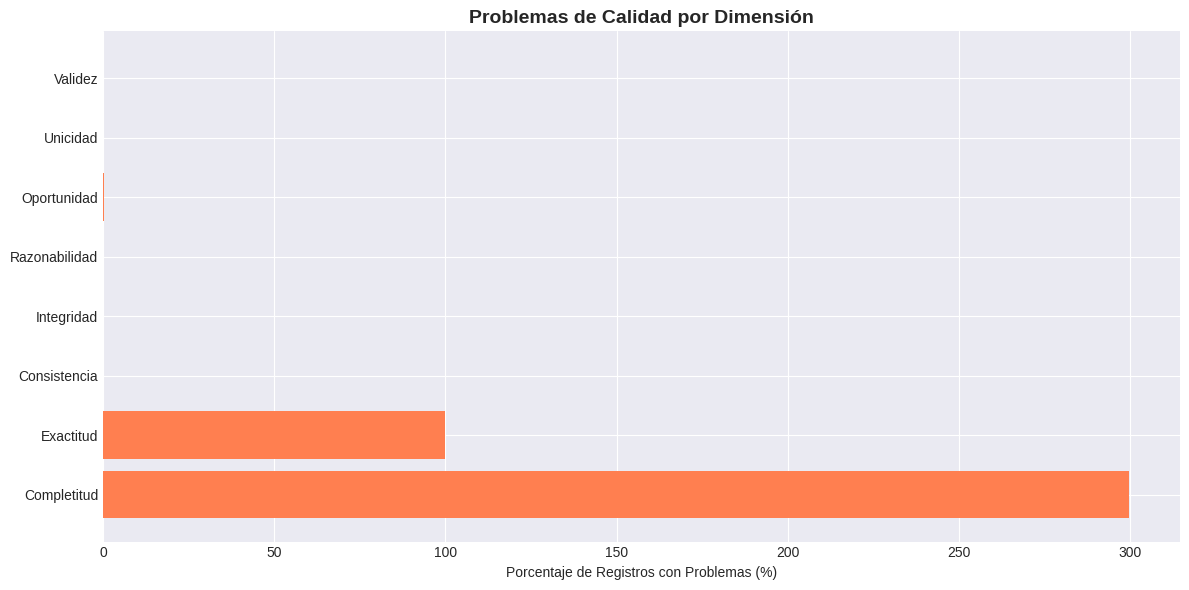

In [13]:
# Generar reporte final
reporte_final = generar_reporte_calidad(df, resultados)

print("REPORTE CONSOLIDADO DE CALIDAD DE DATOS")
print(reporte_final.to_string(index=False))

# Visualización
plt.figure(figsize=(12, 6))
plt.barh(reporte_final['Dimensión'], reporte_final['Porcentaje'], color='coral')
plt.xlabel('Porcentaje de Registros con Problemas (%)')
plt.title('Problemas de Calidad por Dimensión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()